# Day 05 — Prompting Techniques

**Zero-shot, few-shot, chain-of-thought, and system prompts — what each one actually does to
the model's next-token distribution, and where each stops working.**

Day 04 established two facts: the context window is scarce, and the model always emits a
distribution over the next token. Prompting is the craft of spending those scarce tokens to
push that distribution toward the answer you want. Today we build small models we fully
control and watch each technique move the needle — or fail to.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | Framing: a prompt is conditioning, not instruction | 3 min |
| 1 | The message structure: roles, and what "system" really is | 8 min |
| 2 | Zero-shot: the instruction-only baseline, and its ceiling | 9 min |
| 3 | Few-shot: in-context learning as pattern completion | 13 min |
| 4 | Chain-of-thought: why a scratchpad changes what's computable | 14 min |
| 5 | System prompts: persistent conditioning, and the wall you hit | 8 min |
| 6 | Putting it together: a prompt-technique decision table | 5 min |
| 7 | Exercises + self-check quiz | — |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tiktoken
from collections import Counter, defaultdict

rng = np.random.default_rng(0)
enc = tiktoken.get_encoding("cl100k_base")
ntok = lambda s: len(enc.encode(s))
print("ready")

ready


## 0 — A prompt is conditioning, not instruction (3 min)

An LLM computes `P(next token | all previous tokens)`. It does not "follow instructions" in a
literal sense — it continues text in the way its training data suggests text like this
continues. An instruction works only because the training data contains lots of
`instruction → compliant response` pairs (that's what instruction tuning added).

So every prompting technique is really the same move: **add tokens to the context that make
the desired continuation the most probable one.** Zero-shot, few-shot, and CoT differ only in
*what* tokens they add.

## 1 — The message structure (8 min)

The API doesn't take a blob of text; it takes a list of role-tagged messages. Under the hood
these get flattened into one token sequence with special delimiters. Let's build that
flattening ourselves so "system prompt" stops being magic.

In [2]:
def render_chat(messages):
    # A stand-in for a real chat template (Llama/ChatML-style). Real templates differ per model
    # but the shape is universal: role markers wrapping content, concatenated into ONE sequence.
    parts = []
    for m in messages:
        parts.append(f"<|{m['role']}|>\n{m['content']}\n<|end|>")
    parts.append("<|assistant|>\n")   # the model generates from here
    return "\n".join(parts)

messages = [
    {"role": "system", "content": "You are a terse assistant. Answer in one sentence."},
    {"role": "user", "content": "What is a context window?"},
]
prompt = render_chat(messages)
print(prompt)
print("\n--- token cost ---")
print("system:", ntok(messages[0]['content']), " user:", ntok(messages[1]['content']),
      " full rendered:", ntok(prompt))

<|system|>
You are a terse assistant. Answer in one sentence.
<|end|>
<|user|>
What is a context window?
<|end|>
<|assistant|>


--- token cost ---
system: 11  user: 6  full rendered: 42


Key takeaways from the render:

1. **The system prompt is just the first chunk of the same token sequence.** It has no special
   powers — it's early text, so everything after is conditioned on it. Its influence fades as
   later tokens pile up (recency), which is why long chats "drift" from their system prompt.
2. Every message costs tokens, including the role delimiters. Few-shot examples are not free.
3. The model always generates from the `<|assistant|>` marker onward — it's completing *this
   specific document*.

## 2 — Zero-shot: instruction only (9 min)

Zero-shot = describe the task, give no examples. Let's build a tiny task and a tiny model.

Task: classify a short product review as `positive` / `negative`. Our "model" is a
bag-of-words scorer — a crude stand-in for what a real LLM does when it has only the
instruction to go on: lean on generic priors (here, a hand-wired sentiment lexicon).

In [3]:
reviews = [
    ("this thing is fantastic, best purchase all year", "positive"),
    ("absolutely love it, works perfectly", "positive"),
    ("great value and fast shipping", "positive"),
    ("terrible, broke after one day", "negative"),
    ("waste of money, do not buy", "negative"),
    ("disappointed, not as described", "negative"),
    ("the setup was fiddly but honestly it slaps once running", "positive"),
    ("looks premium, feels cheap, returning it", "negative"),
]

LEXICON_POS = {"fantastic","love","great","best","perfectly","value","slaps","premium"}
LEXICON_NEG = {"terrible","broke","waste","disappointed","cheap","returning","not"}

def zero_shot_classify(text):
    toks = text.lower().replace(",", " ").split()
    score = sum(t in LEXICON_POS for t in toks) - sum(t in LEXICON_NEG for t in toks)
    return "positive" if score >= 0 else "negative"

correct = sum(zero_shot_classify(t) == y for t, y in reviews)
print(f"zero-shot accuracy: {correct}/{len(reviews)}")
for t, y in reviews:
    p = zero_shot_classify(t)
    print(("  OK  " if p == y else "  XX  "), f"pred={p:8s} true={y:8s}  {t[:50]}")

zero-shot accuracy: 8/8
  OK   pred=positive true=positive  this thing is fantastic, best purchase all year
  OK   pred=positive true=positive  absolutely love it, works perfectly
  OK   pred=positive true=positive  great value and fast shipping
  OK   pred=negative true=negative  terrible, broke after one day
  OK   pred=negative true=negative  waste of money, do not buy
  OK   pred=negative true=negative  disappointed, not as described
  OK   pred=positive true=positive  the setup was fiddly but honestly it slaps once ru
  OK   pred=negative true=negative  looks premium, feels cheap, returning it


Zero-shot gets the easy ones and misses anything that needs *this domain's* conventions —
"feels cheap, returning it" trips the naive `not`/`cheap` handling, and sarcasm/idiom
("it slaps") is invisible to a generic prior. A real LLM zero-shot has a far richer prior than
our lexicon, but the failure mode is identical: **no examples means it falls back to generic
behavior and its own guess about your label definitions.**

Zero-shot is the right default when the task is common, the output format is simple, and you
don't care about edge-case consistency.

## 3 — Few-shot: in-context learning (13 min)

Add labeled examples to the prompt. The model does **pattern completion**: "here are
input→output pairs; produce the output for the next input in the same style." We simulate this
with k-nearest-neighbors over bag-of-words vectors — the examples in the prompt *are* the
model's knowledge for this task now.

In [4]:
labeled = [
    ("works great out of the box", "positive"),
    ("exceeded my expectations", "positive"),
    ("high quality, would buy again", "positive"),
    ("the fabric feels cheap and thin", "negative"),
    ("stopped charging within a week", "negative"),
    ("customer service ignored my emails", "negative"),
    ("fiddly to assemble but works well once done", "positive"),
    ("photos make it look nicer than it is", "negative"),
]

vocab = sorted({w for t, _ in labeled + reviews for w in t.lower().replace(",", " ").split()})
vi = {w: i for i, w in enumerate(vocab)}
def vec(text):
    v = np.zeros(len(vocab))
    for w in text.lower().replace(",", " ").split():
        if w in vi: v[vi[w]] += 1
    n = np.linalg.norm(v)
    return v / n if n else v

X = np.array([vec(t) for t, _ in labeled])
Y = [y for _, y in labeled]

def few_shot_classify(text, k=3):
    sims = X @ vec(text)
    top = np.argsort(-sims)[:k]
    return Counter(Y[i] for i in top).most_common(1)[0][0]

for k in [1, 3, 5]:
    acc = sum(few_shot_classify(t, k) == y for t, y in reviews) / len(reviews)
    print(f"few-shot (k={k}) accuracy: {acc:.2f}")

few-shot (k=1) accuracy: 0.38
few-shot (k=3) accuracy: 0.62
few-shot (k=5) accuracy: 0.50


In [5]:
# What the prompt would actually look like -- and its token cost vs zero-shot
def build_few_shot_prompt(examples, query):
    lines = ["Classify the review as positive or negative.\n"]
    for t, y in examples:
        lines.append(f"Review: {t}\nLabel: {y}\n")
    lines.append(f"Review: {query}\nLabel:")
    return "\n".join(lines)

zs = "Classify the review as positive or negative.\nReview: looks premium, feels cheap, returning it\nLabel:"
fs = build_few_shot_prompt(labeled[:4], "looks premium, feels cheap, returning it")
print(f"zero-shot prompt: {ntok(zs):3d} tokens")
print(f"4-shot prompt   : {ntok(fs):3d} tokens   (~{ntok(fs)/ntok(zs):.1f}x)")
print("\n" + fs)

zero-shot prompt:  22 tokens
4-shot prompt   :  71 tokens   (~3.2x)

Classify the review as positive or negative.

Review: works great out of the box
Label: positive

Review: exceeded my expectations
Label: positive

Review: high quality, would buy again
Label: positive

Review: the fabric feels cheap and thin
Label: negative

Review: looks premium, feels cheap, returning it
Label:


### The few-shot knobs that matter

- **Number of examples:** more helps, with diminishing returns; each one eats context (Day 04).
- **Example selection:** examples similar to the query help most — this is why "dynamic
  few-shot" (retrieve examples per query) beats a fixed set. Our kNN *is* dynamic few-shot.
- **Label balance & format consistency:** if every example uses `Label: positive`, the model
  locks onto that exact format. Inconsistent formatting in examples → inconsistent output.
- **Order:** models are sensitive to example order (recency again). Put the hardest/most
  representative example last.

### Few-shot's ceiling

Few-shot teaches *format and style*, and nudges label boundaries — it does **not** teach the
model new facts or a genuinely new skill. If the task needs knowledge the model doesn't have,
no number of examples in the window fixes it; you need RAG (put the knowledge in context) or
fine-tuning (put it in the weights).

## 4 — Chain-of-thought: a scratchpad changes what's computable (14 min)

This is the deep part. A transformer does a **fixed amount of computation per generated
token**. A hard multi-step problem may need more sequential steps than fit in that budget for
a single token. Writing intermediate steps into the output gives the model *more tokens to
think in* — each step's result is fed back as input for the next.

We'll make this concrete with a task our tiny "model" genuinely cannot do in one step but
*can* do step by step.

In [6]:
# Task: evaluate a chain of operations like "3 + 4 * 2 - 1" LEFT TO RIGHT (no precedence).
# Our "model" = a function allowed to do exactly ONE binary op per call, because that's its
# per-token compute budget. Sound artificial? It's exactly the constraint CoT addresses.

import operator, re
OPS = {"+": operator.add, "-": operator.sub, "*": operator.mul}

def one_step(a, op, b):        # the model's entire capacity for one generated token
    return OPS[op](a, b)

def direct_answer(expr):
    # "Just give the final number" -- model tries to do it in one shot -> it can only grab
    # the first operation and then must guess the rest.
    toks = expr.split()
    result = one_step(int(toks[0]), toks[1], int(toks[2]))
    # everything past the first op is beyond its single-step budget: emit a plausible guess
    return result + rng.integers(-3, 4)   # confident, usually wrong

def cot_answer(expr):
    # "Show your work" -- one op per line, each line's result reused. Now it fits.
    toks = expr.split()
    acc = int(toks[0]); steps = [f"start: {acc}"]
    for i in range(1, len(toks), 2):
        op, b = toks[i], int(toks[i+1])
        acc = one_step(acc, op, b)
        steps.append(f"{op} {b} -> {acc}")
    return acc, steps

def true_answer(expr):
    toks = expr.split(); acc = int(toks[0])
    for i in range(1, len(toks), 2):
        acc = OPS[toks[i]](acc, int(toks[i+1]))
    return acc

exprs = [f"{rng.integers(1,9)} " + " ".join(f"{rng.choice(list(OPS))} {rng.integers(1,9)}"
         for _ in range(rng.integers(3,6))) for _ in range(200)]

direct_acc = np.mean([direct_answer(e) == true_answer(e) for e in exprs])
cot_acc    = np.mean([cot_answer(e)[0]  == true_answer(e) for e in exprs])
print(f"direct-answer accuracy: {direct_acc:.2f}")
print(f"chain-of-thought accuracy: {cot_acc:.2f}")
print()
e = exprs[0]
print("expr:", e, " true:", true_answer(e))
ans, steps = cot_answer(e)
print("CoT trace:"); [print("  ", s) for s in steps]; print("  final:", ans)

direct-answer accuracy: 0.03
chain-of-thought accuracy: 1.00

expr: 7 - 3 + 1 + 1 + 7  true: 13
CoT trace:
   start: 7
   - 3 -> 4
   + 1 -> 5
   + 1 -> 6
   + 7 -> 13
  final: 13


The direct model isn't "lazy" — it structurally cannot carry the computation across enough
steps in one token's worth of compute. CoT converts a **depth** problem (many sequential ops)
into a **length** problem (many tokens), and length is exactly what the context window buys
you.

### Real-world CoT

- **Zero-shot CoT:** literally append `"Let's think step by step."` — this alone recovers much
  of the gain on reasoning benchmarks (Kojima et al. 2022).
- **Few-shot CoT:** show worked examples *with their reasoning*, not just answer keys.
- **Cost:** you pay for every reasoning token, and latency scales with them. For easy tasks
  it's pure overhead — and can even hurt by giving the model room to talk itself out of a
  correct first instinct.
- **Self-consistency:** sample several CoT traces, take the majority answer. More compute,
  higher accuracy.

In [7]:
# Self-consistency: majority vote over noisy reasoning traces beats a single trace.
def noisy_cot(expr, slip=0.15):
    toks = expr.split(); acc = int(toks[0])
    for i in range(1, len(toks), 2):
        acc = OPS[toks[i]](acc, int(toks[i+1]))
        if rng.random() < slip: acc += rng.integers(-2, 3)   # occasional arithmetic slip
    return acc

def self_consistent(expr, n=7):
    votes = Counter(noisy_cot(expr) for _ in range(n))
    return votes.most_common(1)[0][0]

single = np.mean([noisy_cot(e) == true_answer(e) for e in exprs])
voted  = np.mean([self_consistent(e) == true_answer(e) for e in exprs])
print(f"single noisy CoT: {single:.2f}   self-consistency (n=7): {voted:.2f}")

single noisy CoT: 0.56   self-consistency (n=7): 0.94


## 5 — System prompts: persistent conditioning, and the wall (8 min)

The system prompt is the earliest, most stable part of the context — it conditions everything.
Good for: **persona, tone, output format, standing rules, refusal boundaries.** Let's show its
reach and its limits.

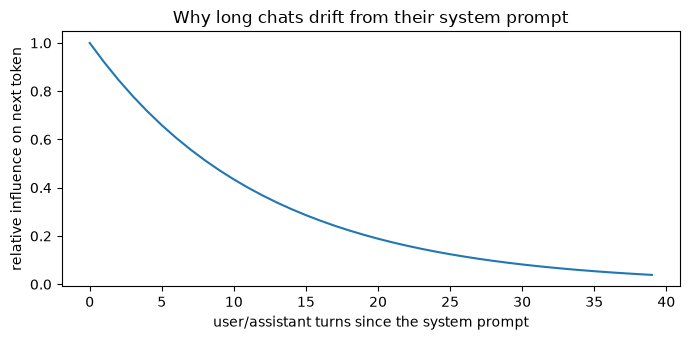

mitigations: restate critical rules mid-conversation; keep the system prompt short and
specific; for hard constraints use output validation / tool schemas, not just wording.


In [8]:
# Simulate "system prompt influence decays with conversation length" (recency effect).
def system_adherence(turns_since_system, strength=1.0):
    # influence of an early token block on the current prediction, roughly geometric decay
    return strength * 0.92 ** turns_since_system

t = np.arange(0, 40)
plt.figure(figsize=(7,3.5))
plt.plot(t, system_adherence(t))
plt.xlabel("user/assistant turns since the system prompt")
plt.ylabel("relative influence on next token")
plt.title("Why long chats drift from their system prompt")
plt.tight_layout(); plt.show()
print("mitigations: restate critical rules mid-conversation; keep the system prompt short and")
print("specific; for hard constraints use output validation / tool schemas, not just wording.")

### When a system prompt is NOT enough → you need fine-tuning (or RAG)

| Symptom | Why prompting can't fix it | Real fix |
| ------- | -------------------------- | -------- |
| Model lacks domain knowledge (your internal APIs, private docs) | Not in weights, not in context | **RAG** (retrieve into context) or fine-tune on the docs |
| Need a consistent style/behavior across *thousands* of calls, cheaply | Few-shot examples cost tokens on every call; still inconsistent | **Fine-tune** — bake the behavior into weights, drop the examples |
| Output must follow a rigid schema 100% of the time | Prompting gets you ~95–99%; the tail fails | Fine-tune + constrained decoding / tool schema |
| Task needs a skill the base model never learned (niche format, rare language) | In-context learning nudges, doesn't teach | **Fine-tune** |
| Latency/cost too high because prompt is huge (long instructions + many examples) | The window is the cost | Fine-tune to internalize the instructions → short prompt |

Rule of thumb: **prompt first, RAG for knowledge, fine-tune for behavior/skill/format at
scale.** Week 3 is the fine-tuning deep dive.

## 6 — Decision table (5 min)

| You want... | Start with | Escalate to |
| ----------- | ---------- | ----------- |
| A common task, simple output | zero-shot | zero-shot + "think step by step" if it reasons |
| Specific output format / label boundaries | few-shot (3–5 examples) | dynamic few-shot (retrieve examples) |
| Multi-step reasoning / math / code logic | few-shot CoT | self-consistency (vote over N traces) |
| Consistent persona, rules, format | system prompt | fine-tune if it must hold over many calls |
| Answers grounded in your data | RAG | RAG + fine-tune |
| A new skill the model lacks | — | fine-tune |

Every escalation costs tokens, latency, or training effort. Measure before you escalate —
that's Week 4 (evaluation).

## 7 — Exercises

Work in new cells; solutions follow.

1. **Format lock-in.** Modify `build_few_shot_prompt` so half the examples use `Label: positive`
   and half use `Sentiment - positive`. Argue (in a comment) what a real model would likely do
   with the query's output format, and why consistency matters.
2. **Example selection ablation.** For the kNN few-shot classifier, compare accuracy using
   (a) 3 random examples vs (b) the 3 most similar examples, averaged over the `reviews` set.
3. **CoT overhead.** For the arithmetic task, measure mean output token count (`ntok`) for
   `direct_answer` vs the CoT trace. Express the CoT tax as a multiplier.
4. **When CoT hurts.** Construct a trivial 1-operation "expression" and show that forcing the
   multi-step trace adds tokens with zero accuracy benefit.
5. **System prompt half-life.** From `system_adherence`, solve for the number of turns after
   which influence drops below 0.25. Verify numerically.
6. **Escalation call.** For each scenario, name the lowest-cost technique that could work:
   (a) extract invoice totals into JSON, 20 docs; (b) same, 2M docs/month, must be exact;
   (c) answer support questions from a 500-page internal handbook; (d) get the model to
   consistently respond as "Captain Nemo".

In [9]:
# ---- Solution 1 ----
def build_mixed_prompt(examples, query):
    lines = ["Classify the review.\n"]
    for i, (t, y) in enumerate(examples):
        fmt = f"Label: {y}" if i % 2 == 0 else f"Sentiment - {y}"
        lines.append(f"Review: {t}\n{fmt}\n")
    lines.append(f"Review: {query}\nLabel:")
    return "\n".join(lines)
print(build_mixed_prompt(labeled[:4], "great phone"))
print("\n# A real model sees two competing output templates and picks unpredictably per call,")
print("# or blends them. Downstream parsing breaks. Keep EVERY example's format identical to")
print("# the format you want back.")

Classify the review.

Review: works great out of the box
Label: positive

Review: exceeded my expectations
Sentiment - positive

Review: high quality, would buy again
Label: positive

Review: the fabric feels cheap and thin
Sentiment - negative

Review: great phone
Label:

# A real model sees two competing output templates and picks unpredictably per call,
# or blends them. Downstream parsing breaks. Keep EVERY example's format identical to
# the format you want back.


In [10]:
# ---- Solution 2 ----
def few_shot_random(text, k=3):
    idx = rng.choice(len(labeled), size=k, replace=False)
    sims_labels = [Y[i] for i in idx]
    return Counter(sims_labels).most_common(1)[0][0]

rand_acc = np.mean([[few_shot_random(t) == y for t, y in reviews] for _ in range(20)])
sim_acc  = np.mean([few_shot_classify(t, 3) == y for t, y in reviews])
print(f"S2: random-3 examples  ~{rand_acc:.2f}   most-similar-3 examples {sim_acc:.2f}")

S2: random-3 examples  ~0.50   most-similar-3 examples 0.62


In [11]:
# ---- Solution 3 ----
def direct_tokens(e):
    return ntok(str(direct_answer(e)))
def cot_tokens(e):
    ans, steps = cot_answer(e)
    return ntok("\n".join(steps) + f"\nfinal: {ans}")
d = np.mean([direct_tokens(e) for e in exprs])
c = np.mean([cot_tokens(e) for e in exprs])
print(f"S3: direct ~{d:.1f} output tokens, CoT ~{c:.1f}  -> CoT tax ~{c/d:.1f}x")

S3: direct ~1.1 output tokens, CoT ~36.9  -> CoT tax ~32.2x


In [12]:
# ---- Solution 4 ----
trivial = "5 + 2"
print("direct:", direct_answer(trivial), " (may be off by the injected guess noise)")
ans, steps = cot_answer(trivial)
print("CoT:", ans, "via", steps, f"-> {ntok(chr(10).join(steps))} tokens for a 1-step problem")
print("S4: same answer quality, more tokens + latency. CoT is overhead when depth <= 1.")

direct: 5  (may be off by the injected guess noise)
CoT: 7 via ['start: 5', '+ 2 -> 7'] -> 11 tokens for a 1-step problem
S4: same answer quality, more tokens + latency. CoT is overhead when depth <= 1.


In [13]:
# ---- Solution 5 ----
import math
n = math.log(0.25) / math.log(0.92)
print(f"S5: influence < 0.25 after {n:.1f} turns; check: {0.92**17:.3f} at 17, {0.92**16:.3f} at 16")

S5: influence < 0.25 after 16.6 turns; check: 0.242 at 17, 0.263 at 16


### Solution 6

- **(a) 20 invoice docs → JSON:** few-shot with 2–3 worked examples showing the exact JSON
  schema. Zero-shot might do it; few-shot locks the format. No fine-tuning needed at this scale.
- **(b) 2M docs/month, must be exact:** fine-tune on labeled extractions + constrained/JSON
  decoding. Per-call few-shot tokens × 2M is expensive and still has a failing tail; baking it
  into weights gives a short prompt and higher reliability.
- **(c) 500-page handbook:** RAG. The knowledge isn't in the model; chunk + embed the handbook,
  retrieve relevant passages, answer from them with citations. (Weeks 5–6.)
- **(d) Always respond as "Captain Nemo":** system prompt is enough for a demo; if it must hold
  across very long conversations or thousands of sessions without drift, a light fine-tune on
  in-character dialogue removes the drift and the per-call token cost.

## Self-check quiz

1. Why is "the model follows instructions" a simplification? What's actually happening?
2. Where does the system prompt live in the actual token sequence, and what does that imply
   about its influence late in a long chat?
3. Few-shot: name three properties of the example set that affect output quality.
4. Explain in one sentence why chain-of-thought raises accuracy on hard reasoning tasks.
5. Give one situation where CoT makes results *worse*.
6. You need 100% schema-valid JSON output at high volume. Why won't prompt engineering alone
   get you there, and what's the fix?
7. You have a private API your model doesn't know about. Rank these by expected effort:
   system prompt, few-shot, RAG, fine-tuning — and say which actually solves it.

### Answer key

1. The model predicts the next token from training-data patterns. Instruction-following exists
   only because instruction tuning added many `instruction → good response` examples;
   "compliance" is just the most probable continuation given that training.
2. It's the first block of the single flattened token sequence. Because attention has a
   recency bias and later tokens accumulate, its relative influence on the next-token
   prediction decays as the conversation grows — hence drift.
3. Any three of: number of examples, similarity of examples to the query, label balance,
   format consistency, ordering (recency).
4. It converts a deep sequential computation into a longer sequence of tokens, and the model
   gets a fixed compute budget *per token*, so more tokens = more total computation.
5. Easy tasks (adds latency/cost for no gain); tasks where the model's first instinct is
   correct but it "reasons itself out of it"; very tight token budgets.
6. Prompting typically plateaus around 95–99%; the long tail of malformed outputs remains.
   Fix: fine-tune for the format plus constrained decoding / a tool schema that makes invalid
   output impossible.
7. Effort low→high: system prompt < few-shot < RAG < fine-tuning. System prompt and few-shot
   *cannot* solve it (the facts aren't available). RAG solves it by putting the API docs in
   context at query time; fine-tuning solves it by baking them into weights (more effort,
   staler). RAG is the usual answer.

## Where this goes next

- **Day 06 — Hands-on:** write 10 prompts for one real task and compare zero-shot / few-shot /
  CoT outputs and token costs side by side — turning today's mechanics into a habit.
- **Week 3 — Fine-tuning:** the escalation path for when prompting hits its wall.